In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [2]:
# Load Iris Dataset

iris = load_iris(as_frame=True)

df = iris.frame.copy()

# Convert target numbers into flower names
df["species"] = df["target"].map(
    dict(enumerate(iris.target_names))
)

# Remove target number column
df = df.drop(columns=["target"])

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Check data types

print("Data Types:")
display(df.dtypes)

# Check missing values

print("Missing Values:")
display(df.isnull().sum())

# Statistical summary

print("Descriptive Statistics:")
display(df.describe())

Data Types:


,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,object


Missing Values:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


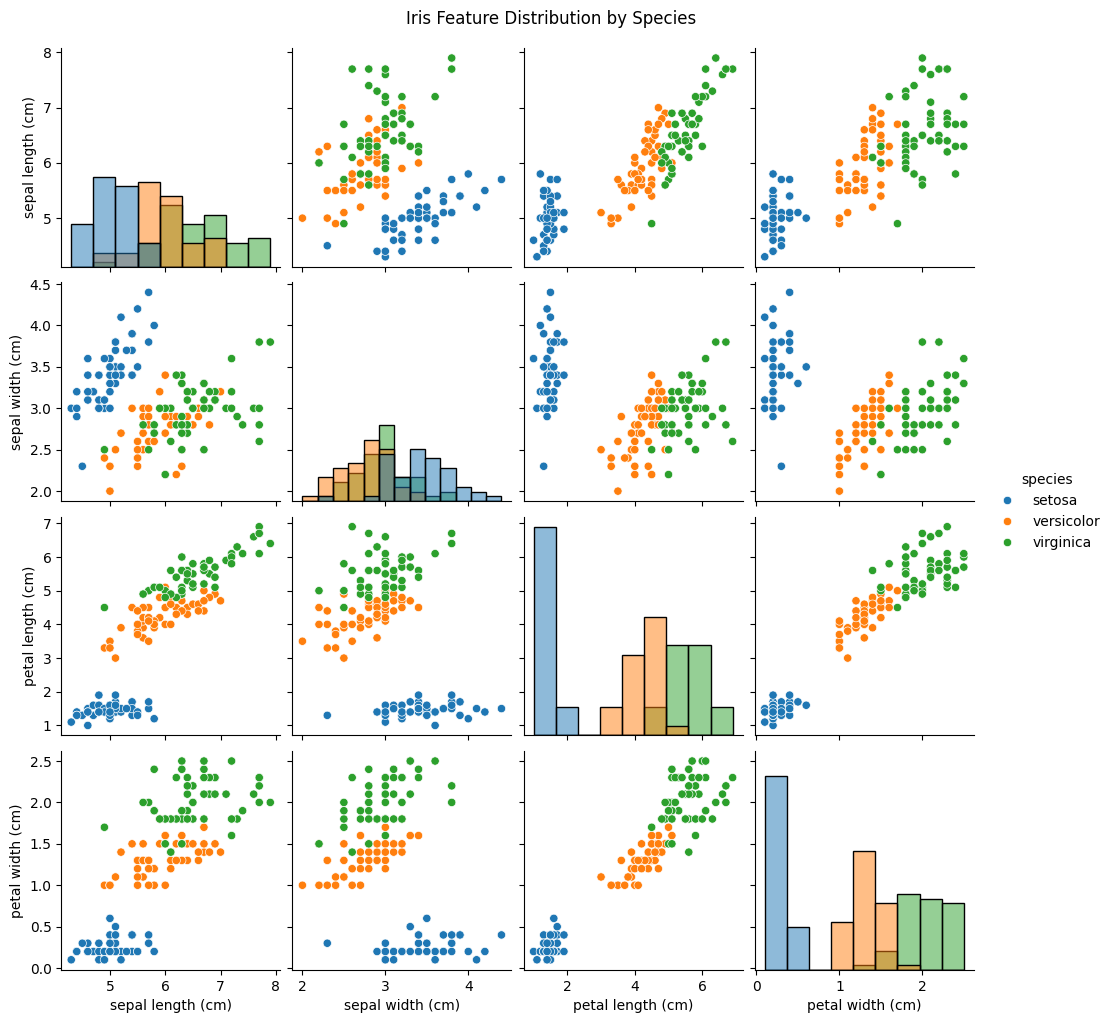

In [6]:
# Pairplot to compare Iris flower features

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Iris Feature Distribution by Species",
    y=1.02
)

plt.show()

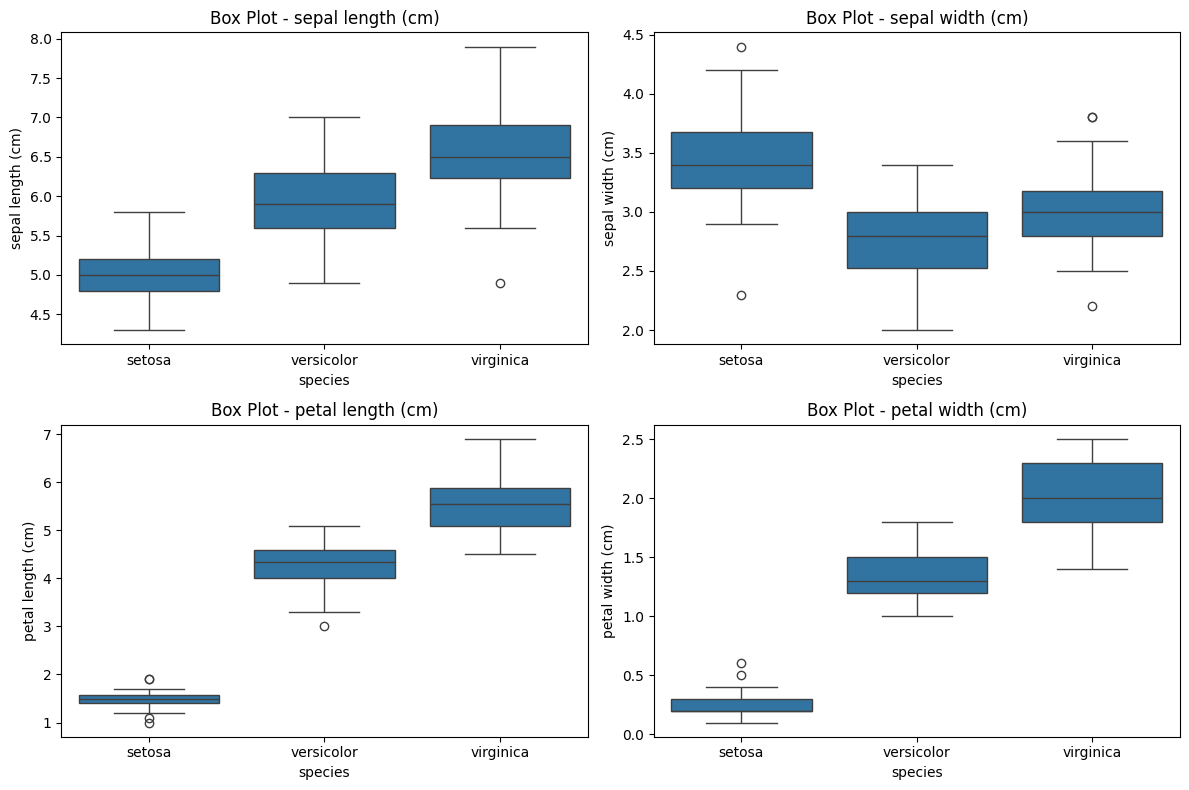

In [7]:
# Box plots for all Iris features

features = iris.feature_names

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        ax=ax
    )

    ax.set_title(f"Box Plot - {feature}")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
# Create Logistic Regression model

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
logistic_pred = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Accuracy:", logistic_accuracy)

# Classification report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        logistic_pred
    )
)

Logistic Regression Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [17]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:",
      rf_accuracy)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [18]:
from sklearn.metrics import confusion_matrix

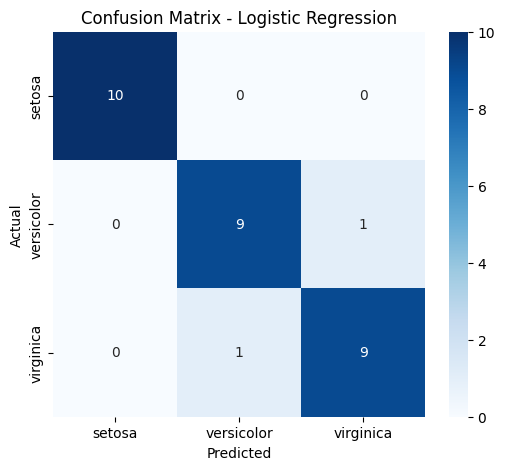

In [19]:
# Confusion Matrix - Logistic Regression

cm = confusion_matrix(
    y_test,
    logistic_pred,
    labels=iris.target_names
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

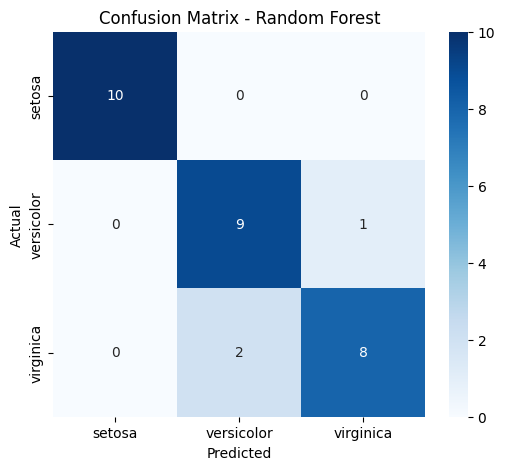

In [20]:
# Confusion Matrix - Random Forest

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=iris.target_names
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
# Compare model accuracy

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

display(results)

,Model,Accuracy
0,Logistic Regression,0.933333
1,Random Forest,0.900000


In [22]:
# Select the best-performing model

if rf_accuracy > logistic_accuracy:
    best_model = "Random Forest"
    best_accuracy = rf_accuracy
else:
    best_model = "Logistic Regression"
    best_accuracy = logistic_accuracy

print("Best Model:", best_model)
print("Best Accuracy:", best_accuracy)

Best Model: Logistic Regression
Best Accuracy: 0.9333333333333333


In [23]:
print("""
Conclusion:

Two classification models were trained:
1. Logistic Regression
2. Random Forest

Both models were evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report

The model with the highest accuracy was selected
as the best-performing model.
""")


Conclusion:

Two classification models were trained:
1. Logistic Regression
2. Random Forest

Both models were evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report

The model with the highest accuracy was selected
as the best-performing model.

